# Inférence — CNN sur le dataset GTSRB Test

Ce notebook teste le modèle `cnn_gtsrb.pth` sur le dataset officiel **GTSRB_Final_Test_Images.zip**.

On utilise **40 % du dataset test** pour l'inférence.


## 1. Import des librairies

In [1]:
import os
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

from torchvision import transforms
import matplotlib.pyplot as plt

print("Version de PyTorch :", torch.__version__)

Version de PyTorch : 2.10.0+cpu


## 2. Télécharger le dataset test officiel

In [2]:
!rm -rf GTSRB
!rm -f GTSRB_Final_Test_Images.zip*
!rm -f GTSRB_Final_Test_GT.zip*

!wget https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip
!wget https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip

!unzip -q GTSRB_Final_Test_Images.zip
!unzip -q GTSRB_Final_Test_GT.zip

--2026-05-03 10:51:08--  https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip
Resolving sid.erda.dk (sid.erda.dk)... 130.225.104.13
Connecting to sid.erda.dk (sid.erda.dk)|130.225.104.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 88978620 (85M) [application/zip]
Saving to: ‘GTSRB_Final_Test_Images.zip’

GTSRB_Final_Test_Im 100%[===================>]  84.86M  15.2MB/s    in 5.6s    

2026-05-03 10:51:14 (15.1 MB/s) - ‘GTSRB_Final_Test_Images.zip’ saved [88978620/88978620]

--2026-05-03 10:51:14--  https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip
Resolving sid.erda.dk (sid.erda.dk)... 130.225.104.13
Connecting to sid.erda.dk (sid.erda.dk)|130.225.104.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 99620 (97K) [application/zip]
Saving to: ‘GTSRB_Final_Test_GT.zip’

GTSRB_Final_Test_GT 100%[===================>]  97.29K   421KB/s    in 0.2s    

## 3. Définir les chemins

In [3]:
test_images_dir = "/content/GTSRB/Final_Test/Images"
csv_path = "/content/GT-final_test.csv"

print("Dossier courant :", os.getcwd())
print("Images test existe :", os.path.exists(test_images_dir))
print("CSV existe :", os.path.exists(csv_path))

if os.path.exists(test_images_dir):
    print("Exemples d'images :", os.listdir(test_images_dir)[:5])

Dossier courant : /content
Images test existe : True
CSV existe : True
Exemples d'images : ['10373.ppm', '05965.ppm', '00440.ppm', '03966.ppm', '05882.ppm']


## 4. Prétraitement des images

In [4]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.3403, 0.3121, 0.3214],
        std=[0.2724, 0.2608, 0.2669]
    )
])

## 5. Dataset personnalisé pour le dataset test

In [5]:
class GTSRBTestDataset(Dataset):
    def __init__(self, images_dir, csv_path, transform=None):
        self.images_dir = images_dir
        self.data = pd.read_csv(csv_path, sep=";")
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.item()

        idx = int(idx)

        row = self.data.iloc[idx]

        image_path = os.path.join(self.images_dir, row["Filename"])
        image = Image.open(image_path).convert("RGB")

        label = int(row["ClassId"])

        if self.transform:
            image = self.transform(image)

        return image, label

## 6. Charger le dataset test

In [6]:
full_test_dataset = GTSRBTestDataset(
    images_dir=test_images_dir,
    csv_path=csv_path,
    transform=transform
)

print("Nombre total d'images test :", len(full_test_dataset))

Nombre total d'images test : 12630


## 7. Prendre 40 % du dataset test

In [7]:
test_size = int(0.40 * len(full_test_dataset))

indices = torch.randperm(
    len(full_test_dataset),
    generator=torch.Generator().manual_seed(42)
)[:test_size].tolist()

test_subset = Subset(full_test_dataset, indices)

test_loader = DataLoader(
    test_subset,
    batch_size=64,
    shuffle=False
)

print("Nombre d'images utilisées pour l'inférence :", len(test_subset))
print("Nombre de batchs :", len(test_loader))

Nombre d'images utilisées pour l'inférence : 5052
Nombre de batchs : 79


## 8. Définir l'architecture CNN

In [13]:
class CNN_model(nn.Module):
    def __init__(self, num_classes=43):
        super(CNN_model, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 64 -> 32
        x = self.pool(F.relu(self.conv2(x)))  # 32 -> 16
        x = self.pool(F.relu(self.conv3(x)))  # 16 -> 8

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

## 9. Charger le modèle sauvegardé

Avant cette étape, importer `cnn_gtsrb.pth` dans Colab.

Le modèle doit être ici :

```text
/content/cnn_gtsrb.pth
```


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)
model_path = "/content/cnn_gtsrb.pth"
model = CNN_model(num_classes=43).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

print("Modèle chargé avec succès.")

Device utilisé : cpu
Modèle chargé avec succès.


## 10. Évaluation sur 40 % du dataset test

In [15]:
correct = 0
total = 0

all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predictions = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = correct / total
print(f"Accuracy sur 40 % du dataset test : {accuracy:.4f}")

Accuracy sur 40 % du dataset test : 0.9398


## 11. Fonction de dénormalisation

In [11]:
def denormalize(img):
    mean = torch.tensor([0.3403, 0.3121, 0.3214]).view(3, 1, 1)
    std = torch.tensor([0.2724, 0.2608, 0.2669]).view(3, 1, 1)
    return img * std + mean

## 12. Afficher quelques prédictions

<Figure size 1200x600 with 0 Axes>

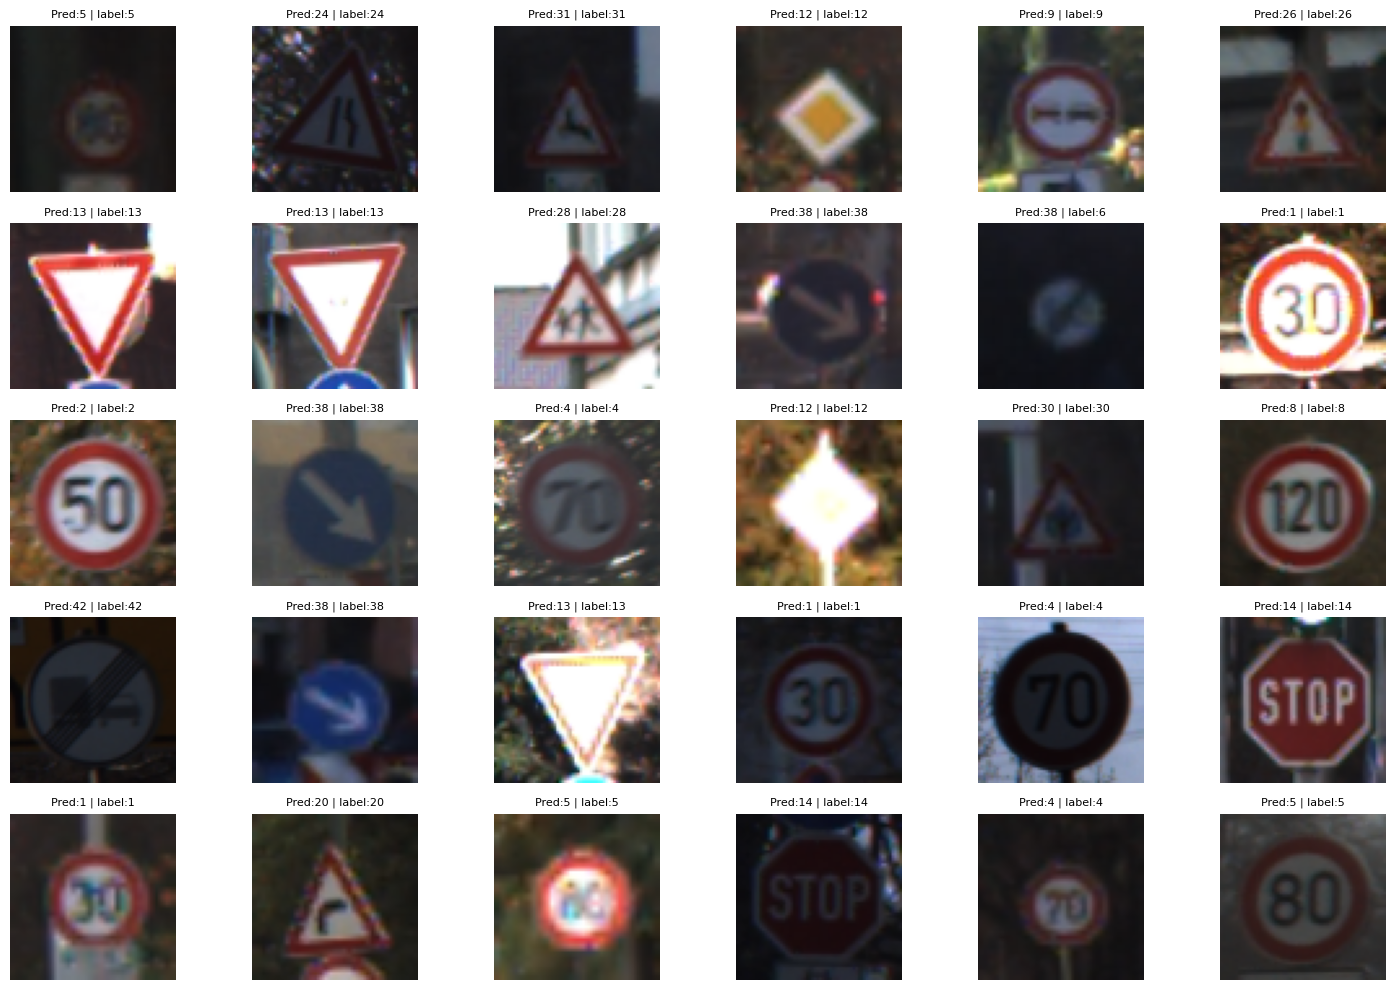

<Figure size 640x480 with 0 Axes>

In [18]:
images, labels = next(iter(test_loader))

images_device = images.to(device)

with torch.no_grad():
    outputs = model(images_device)
    _, predictions = torch.max(outputs, 1)

plt.figure(figsize=(12, 6))

n = 30
cols = 6
rows = (n + cols - 1) // cols

plt.figure(figsize=(15, 10))

for i in range(n):
    img = denormalize(images[i])
    img = img.permute(1, 2, 0)
    img = torch.clamp(img, 0, 1)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(f"Pred:{predictions[i].item()} | label:{labels[i].item()}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()